# End-to-End Exploratory Data Analysis on the Iris Dataset



## Section 1 — What Is EDA?

### 1. Simple definition
**Exploratory Data Analysis (EDA)** is the process of looking closely at a dataset — using numbers,
tables, and pictures — *before* you do anything else with it, so that you truly understand what is
inside it.

### 2. definition
EDA is a  process used to understand the structure, quality, distributions, and
relationships within a dataset in order to guide data cleaning, feature engineering, model selection,
and risk assessment (e.g. data leakage) for a machine learning project.


### 4. Why EDA comes before ML
- It tells you if the data is *trustworthy* (missing values, duplicates, wrong types, weird outliers).
- It tells you if the data is *sufficient* (enough examples per class, informative features).
- It tells you what *preprocessing* will be needed (scaling, encoding, imputation).
- It tells you what results to *expect*, so you can sanity-check your model later.
- It helps you spot **data leakage** before it silently ruins your evaluation.

### 5. What can go wrong if EDA is skipped
- You might train a model on a column that leaks the answer (data leakage) and think it "performs great,"
  when in reality it will fail in production.
- You might not notice that 95% of your data belongs to one class (severe class imbalance), and then be
  confused why your model always predicts the same class.
- You might not notice that a numeric column was accidentally stored as text, causing errors or silent
  bugs.





In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from scipy import stats

# Reproducibility: fixing the random seed ensures our results
# (train/test splits, etc.) are the same every time we run the notebook.
RANDOM_STATE = 42


print("Libraries imported successfully.")


Libraries imported successfully.


## Section 4 — Load the Dataset




In [58]:
iris = load_iris()

In [3]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [5]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [6]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [7]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [8]:
# target labels
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

### Let's make pd df

In [9]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [10]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [11]:
df["species_code"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
df["species"] = iris.target_names[iris.target]

## Section 5 — First Data Inspection




In [13]:
# First 5 rows - a quick visual sanity check of the data
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [14]:
df.head(8)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa


In [15]:
# Last 5 rows - useful to check the data wasn't cut off or corrupted at the end
df.tail()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [16]:
df.tail(7)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
143,6.8,3.2,5.9,2.3,2,virginica
144,6.7,3.3,5.7,2.5,2,virginica
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [17]:
df.sample()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
104,6.5,3.0,5.8,2.2,2,virginica


In [18]:
# A random sample of 5 rows - useful because head()/tail() can hide
# problems that only show up in the middle of the dataset
df.sample(10)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
146,6.3,2.5,5.0,1.9,2,virginica
26,5.0,3.4,1.6,0.4,0,setosa
29,4.7,3.2,1.6,0.2,0,setosa
75,6.6,3.0,4.4,1.4,1,versicolor
3,4.6,3.1,1.5,0.2,0,setosa
59,5.2,2.7,3.9,1.4,1,versicolor
62,6.0,2.2,4.0,1.0,1,versicolor
118,7.7,2.6,6.9,2.3,2,virginica
72,6.3,2.5,4.9,1.5,1,versicolor
13,4.3,3.0,1.1,0.1,0,setosa


In [19]:
# df.shape returns (number_of_rows, number_of_columns)
# Rows = observations (individual flowers)
# Columns = variables/features (+ target)
df.shape


(150, 6)

In [20]:
# The names of every column in the dataset
df.columns


Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species_code', 'species'],
      dtype='object')

In [21]:
# The data type stored in each column
# float64 = decimal number, object = text (string)
df.dtypes


sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species_code           int64
species               object
dtype: object

### Genereal Overview of Dataset

In [22]:
# A compact summary: column names, non-null counts, and data types all at once
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species_code       150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


## Statistical Overview of a Dataset

In [23]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Data Cleaning and Preprocessing

### Cleaning Column names

In [24]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species_code', 'species'],
      dtype='object')

In [25]:
df.columns = df.columns.str.strip()

## Handling Datatypes (typecasting)

In [26]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species_code           int64
species               object
dtype: object

In [27]:
df["species_code"] = df["species_code"].astype("float64")


In [28]:
df["species_code"].dtype  # note: for single feature its is dtype and for multi feature it is dtypes

dtype('float64')

In [29]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species_code         float64
species               object
dtype: object

## Renaming Column

In [30]:
df.rename(columns={'species':'target'}, inplace=True)


In [31]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,target
0,5.1,3.5,1.4,0.2,0.0,setosa
1,4.9,3.0,1.4,0.2,0.0,setosa
2,4.7,3.2,1.3,0.2,0.0,setosa
3,4.6,3.1,1.5,0.2,0.0,setosa
4,5.0,3.6,1.4,0.2,0.0,setosa


### Handling Missing Values
- remove (less data? , drop missing column)
- **Imputation:** fill by mean, mode, medain, by custum value
- ffill, bfill ( Time-series data,
Stock prices,
Sensor readings,
Weather measurements,
Patient/IoT measurements over time,
Status/state data)
- custom value
- model-based approaches

In [32]:
df.isna().sum()
# df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_code         0
target               0
dtype: int64

In [33]:
# checking missing value in a single feature
df['petal length (cm)'].isna().sum()

np.int64(0)

C:\Users\ok\AppData\Local\Temp\ipykernel_1048\3590315865.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['petal length (cm)'], shade=True)


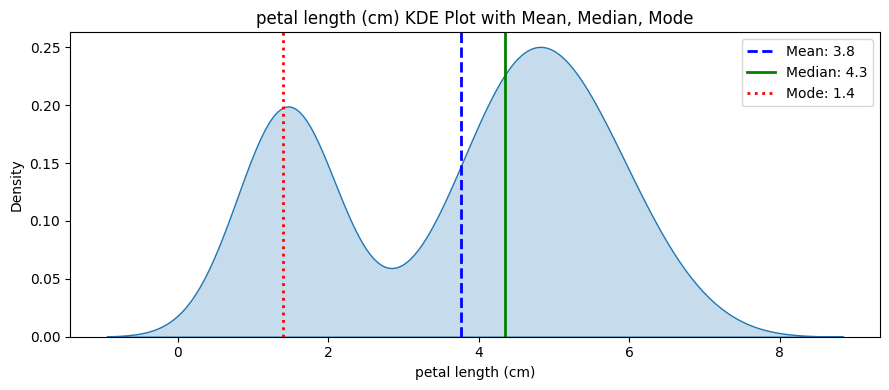

In [61]:
# Calculations
mean_val = np.mean(df['petal length (cm)'])
median_val = np.median(df['petal length (cm)'])
mode_val = stats.mode(df['petal length (cm)'], keepdims=True)[0][0]
plt.figure(figsize=(9, 4))
# KDE plot
sns.kdeplot(df['petal length (cm)'], shade=True)



# Vertical lines
plt.axvline(mean_val, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='solid', linewidth=2, label=f'Median: {median_val:.1f}')
plt.axvline(mode_val, color='red', linestyle='dotted', linewidth=2, label=f'Mode: {mode_val:.1f}')

# Titles and labels
plt.title(f"{'petal length (cm)'} KDE Plot with Mean, Median, Mode")
plt.xlabel('petal length (cm)')
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


In [62]:
df['petal length (cm)'].skew()

np.float64(-0.27488417975101276)

#### Note 
- for Right and Left Skewness use median for filling missing values
- for Symmetric/normal/no skewness then use mean for filling missing values


In [ ]:
# df["column_name"] = df["column_name"].ffill()

# or

# df['sepal length (cm)'].ffill(inplace=True)

C:\Users\ok\AppData\Local\Temp\ipykernel_1048\504331030.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sepal length (cm)'].ffill(inplace=True)


In [ ]:
# df["column_name"] = df["column_name"].bfill()

In [ ]:
# df["column_name"] = df["column_name"].fillna(custom_value)


In [ ]:
# df["column_name"] = df["column_name"].fillna(df['colunm'].mean())

In [ ]:
# df["column_name"] = df["column_name"].fillna(df['colunm'].median())

In [ ]:
# df["column_name"] = df["column_name"].fillna(df['colunm'].mode()[0])  # we will use the first mode


In [39]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species_code', 'target'],
      dtype='object')

In [42]:
df.iloc[: ,-1]

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: target, Length: 150, dtype: object

In [51]:
df.iloc[:, -2]

0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
145    2.0
146    2.0
147    2.0
148    2.0
149    2.0
Name: species_code, Length: 150, dtype: float64

In [52]:
df.iloc[:, -2:]

,species_code,target
0,0.0,setosa
1,0.0,setosa
2,0.0,setosa
3,0.0,setosa
4,0.0,setosa
...,...,...
145,2.0,virginica
146,2.0,virginica
147,2.0,virginica
148,2.0,virginica


In [ ]:
continous_features = df.columns[: -2]
continous_features

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

C:\Users\ok\AppData\Local\Temp\ipykernel_1048\3486194726.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[column], shade=True)


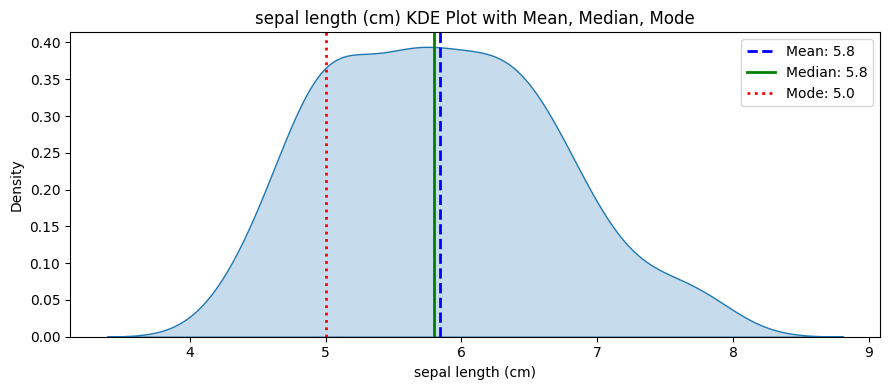

0.3149109566369728


C:\Users\ok\AppData\Local\Temp\ipykernel_1048\3486194726.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[column], shade=True)


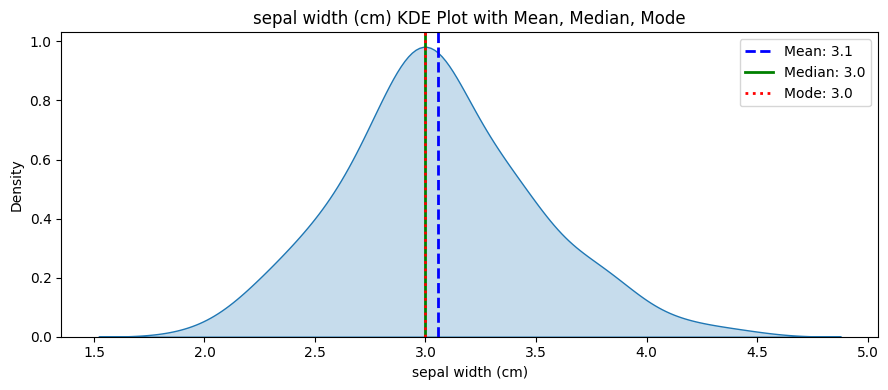

0.31896566471359966


C:\Users\ok\AppData\Local\Temp\ipykernel_1048\3486194726.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[column], shade=True)


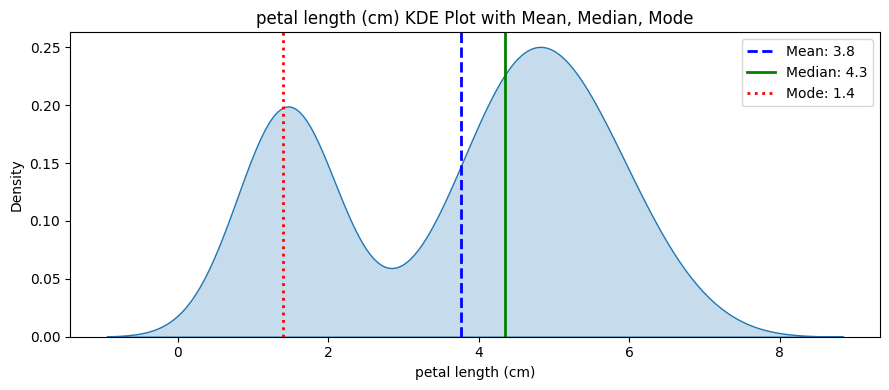

-0.27488417975101276


C:\Users\ok\AppData\Local\Temp\ipykernel_1048\3486194726.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[column], shade=True)


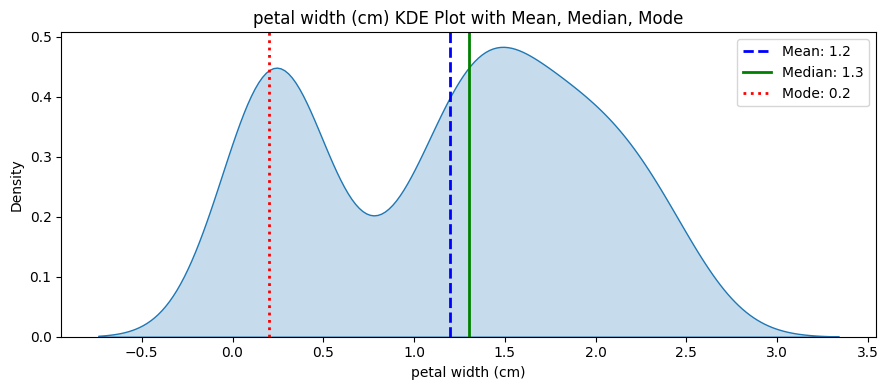

-0.10296674764898116


In [64]:

# Loop through each numeric column
for column in continous_features:
    # Calculations
    mean_val = np.mean(df[column])
    median_val = np.median(df[column])
    mode_val = stats.mode(df[column], keepdims=True)[0][0]
    plt.figure(figsize=(9, 4))

    # KDE plot
    sns.kdeplot(df[column], shade=True)



    # Vertical lines
    plt.axvline(mean_val, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.1f}')
    plt.axvline(median_val, color='green', linestyle='solid', linewidth=2, label=f'Median: {median_val:.1f}')
    plt.axvline(mode_val, color='red', linestyle='dotted', linewidth=2, label=f'Mode: {mode_val:.1f}')

    # Titles and labels
    plt.title(f'{column} KDE Plot with Mean, Median, Mode')
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(df[column].skew())


## Handling Duplicates

In [57]:
# num_duplicates = df.duplicated().sum()
# print(f"Number of duplicate rows: {num_duplicates}")

# df[df.duplicated(keep=False)].sort_values(by=feature_columns)


In [58]:
df.duplicated().sum()

np.int64(1)

In [59]:
# keep= 'first', or 'last'  by default first
df.drop_duplicates(inplace=True) 
# df = df.drop_duplicates()

In [60]:
df.duplicated(subset=['sepal length (cm)', 'sepal width (cm)'])

0      False
1      False
2      False
3      False
4      False
       ...  
145     True
146     True
147     True
148    False
149     True
Length: 149, dtype: bool

## Finding Correlation

In [61]:
df.corr()

ValueError: could not convert string to float: 'setosa'

In [62]:
df.select_dtypes(exclude='O').corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
sepal length (cm),1.000000,-0.118129,0.873738,0.820620,0.786971
sepal width (cm),-0.118129,1.000000,-0.426028,-0.362894,-0.422987
petal length (cm),0.873738,-0.426028,1.000000,0.962772,0.949402
petal width (cm),0.820620,-0.362894,0.962772,1.000000,0.956514
species_code,0.786971,-0.422987,0.949402,0.956514,1.000000


In [63]:
df.select_dtypes(exclude='O').corr().T

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
sepal length (cm),1.000000,-0.118129,0.873738,0.820620,0.786971
sepal width (cm),-0.118129,1.000000,-0.426028,-0.362894,-0.422987
petal length (cm),0.873738,-0.426028,1.000000,0.962772,0.949402
petal width (cm),0.820620,-0.362894,0.962772,1.000000,0.956514
species_code,0.786971,-0.422987,0.949402,0.956514,1.000000


<Axes: >

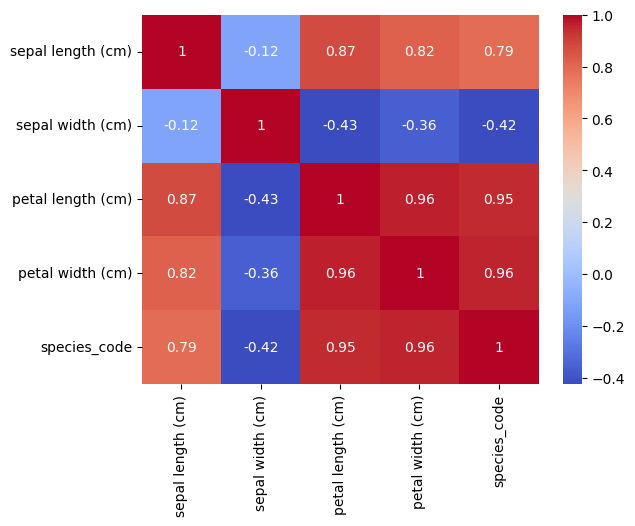

In [64]:
sns.heatmap( df.select_dtypes(exclude='O').corr() , annot=True , cmap='coolwarm') 

In [65]:
# Calculate the correlation matrix for numerical columns
corr_matrix = df.select_dtypes(exclude='O').corr()

In [66]:
corr_matrix['species_code']  # how each numerical feature is correlated with the species_code feature.

sepal length (cm)    0.786971
sepal width (cm)    -0.422987
petal length (cm)    0.949402
petal width (cm)     0.956514
species_code         1.000000
Name: species_code, dtype: float64

In [67]:
# Correlation with target
# not include the species_code featue in cor_matrix
corr_matrix["species_code"].drop("species_code")

sepal length (cm)    0.786971
sepal width (cm)    -0.422987
petal length (cm)    0.949402
petal width (cm)     0.956514
Name: species_code, dtype: float64

#### Find MultiCollinearity b/w Independent Features

In [68]:
# A fun which check the a correaltion among the independent variables
def correlation(df , threshould):
    corr_columns = set()   # A set of columns that have high correlation with each other
    corr_matrix = df.corr()
    for i in  range(0 , len(corr_matrix.columns)):
        for j in range( i ):
            if abs(corr_matrix.iloc[i][j]) > threshould:
                column = corr_matrix.columns[i]
                corr_columns.add(column)
        
    return corr_columns



In [69]:
numerical_columns = df.select_dtypes(exclude="O")
numerical_columns

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [70]:
high_corr_columns = correlation(numerical_columns, 0.90) # collect all the correlated columns
high_corr_columns

C:\Users\ok\AppData\Local\Temp\ipykernel_20444\2758116402.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if abs(corr_matrix.iloc[i][j]) > threshould:


{'petal width (cm)', 'species_code'}

## Checking Class Imbalance

In [71]:
df['target'].value_counts()

target
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

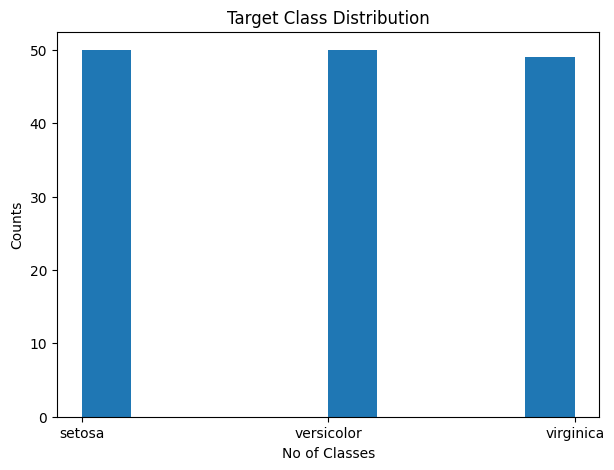

In [72]:
plt.figure(figsize=(7,5))
plt.hist(df['target'])
plt.title('Target Class Distribution')
plt.xlabel("No of Classes")
plt.ylabel("Counts")
plt.show()

### 8.4 Unique Values


In [76]:
df['target'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [77]:
df.nunique()

sepal length (cm)    35
sepal width (cm)     23
petal length (cm)    43
petal width (cm)     22
species_code          3
target                3
dtype: int64

In [78]:
df['petal length (cm)'].unique()

array([1.4, 1.3, 1.5, 1.7, 1.6, 1.1, 1.2, 1. , 1.9, 4.7, 4.5, 4.9, 4. ,
       4.6, 3.3, 3.9, 3.5, 4.2, 3.6, 4.4, 4.1, 4.8, 4.3, 5. , 3.8, 3.7,
       5.1, 3. , 6. , 5.9, 5.6, 5.8, 6.6, 6.3, 6.1, 5.3, 5.5, 6.7, 6.9,
       5.7, 6.4, 5.4, 5.2])

In [79]:
len(df['petal length (cm)'].unique())

43

## Droping Feature

In [80]:
df.drop(columns=['species_code'], inplace = True)

In [81]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


##  Create Independent (X)   and  Dependedent Fature (y)


In [82]:
feature_columns = ["sepal length (cm)", "sepal width (cm)",
                    "petal length (cm)", "petal width (cm)"]

X = df[feature_columns].copy()
y = df["target"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (149, 4)
y shape: (149,)


In [83]:
X.ndim

2

In [84]:
y.ndim

1

In [85]:
X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [86]:
y.head()


0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: target, dtype: object

## Train test split

In [87]:
from sklearn.model_selection import train_test_split

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [89]:
X_train.shape, X_test.shape

((119, 4), (30, 4))

In [90]:
print(f"No of samples in training set : {X_train.shape[0]}")

No of samples in training set : 119


In [92]:
print(f"No of samples in test set : {len(X_test)}")

No of samples in test set : 30


In [93]:
y_train

22         setosa
15         setosa
65     versicolor
11         setosa
42         setosa
          ...    
71     versicolor
106     virginica
14         setosa
92     versicolor
102     virginica
Name: target, Length: 119, dtype: object

## Label Encoding

In [94]:

from sklearn.preprocessing import LabelEncoder

In [95]:
encoder = LabelEncoder()

In [96]:
y_train = encoder.fit_transform(y_train)

In [97]:
y_test = encoder.transform(y_test)

In [98]:
y_train

array([0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2,
       1, 0, 2, 1, 0, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 1, 2,
       1, 1, 2, 1, 0, 2, 2, 0, 0, 1, 1, 0, 2, 0, 0, 1, 1, 1, 2, 2, 1, 0,
       0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 1,
       1, 1, 0, 1, 1, 0, 1, 2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2, 1,
       1, 2, 2, 0, 1, 2, 0, 1, 2])

In [99]:
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [101]:
# # Check mapping
# print("Class mapping:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))